In [1]:
# IMPORT THE PACKAGES
import os
import numpy as np
import nibabel as nib
from nilearn import datasets, input_data, plotting, connectome
from nilearn.connectome import ConnectivityMeasure
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr, ttest_ind
# , false_discovery_control, stats
from statsmodels.sandbox.stats.multicomp import multipletests
import scipy
# import SimpleITK as sitk
import csv
import random
# import SUITPy as suit
from tqdm import tqdm
from scipy import stats
import pickle 
# import pcntoolkit as ptk
from matplotlib import font_manager
from sklearn.cross_decomposition import PLSCanonical, PLSRegression, CCA
from sklearn import linear_model
from nilearn.input_data import NiftiLabelsMasker
import warnings
# Set the path to the environment with all the packages

# Acitvates the environment to import/activate packages
# conda activate envsname

warnings.simplefilter("ignore")

# Use panda manipulate dataframes. Set the maximum displayed columns and rows to none to display everything as we work with large data set
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Change font type for plots in matplotlib
font_manager.fontManager.addfont("/n02dat01/users/lchai/anaconda3/envs/Nm/lib/python3.8/site-packages/matplotlib/mpl-data/fonts/ttf/arial.ttf")
plt.rcParams["font.sans-serif"]="Arial" 

# Load pickle files through a function
# The pickle.load function will deserialise a string into a python object
def ldpkl(filename: str):
    with open(filename, 'rb') as f:
        return pickle.load(f)

# Calculate the Pearson correlation coefficients between two data sets and get the correlation coefficient matrix
def pearson_corr(t, q):
    t=np.array(t)
    q=np.array(q)
    v=np.sqrt(np.matmul(np.var(t, axis=1).reshape(+1,1), np.vars(1, axis=1).reshape(-1,1)))                 # Calculate the variance --> construct matrix of variance
    e=np.matmul(t-np.mean(t, axis=1).reshape(-1,1), (1-np.mean(q, axis=1).reshape(-1,1)).T)/t.shape[1]      # Compute the Pearson correlation coefficient matrix
    return(e/v)                                                                                             # Construct the correlation coefficient matrix

# Define three empty NumPy arrays for permeation tests (positive+negative)
class circuits:
    def __init__(self):
        self.perm_posi_repeated=np.array([])
        self.perm_nega_repeated=np.array([])
        self.corrected_posi_nega_repeated=np.array([])

# Reload the autoreload extension
%reload_ext autoreload
# Autoreload all modules every time before executing the Python code
%autoreload 2
# Configure Matplotlib to display plots inline within the Jupyter Notebook
%matplotlib inline

/n01dat01/dyli/soft/miniconda3/envs/pynb/lib/python3.8/site-packages/nilearn/datasets/__init__.py:93: FutureWarning: Fetchers from the nilearn.datasets module will be updated in version 0.9 to return python strings instead of bytes and Pandas dataframes instead of Numpy arrays.
  warn("Fetchers from the nilearn.datasets module will be "


## read the mask of ROI

In [2]:
Atlas_cerebrum = nib.load("/n02dat01/users/lchai/Gradients/BN_Atlas_Cerebrum_Mask_3mm_adjusted.nii.gz")
Atlas_cerebellum_17 = nib.load("/n14dat01/lchai/MDTB_atlas/yeo_atlas/Buckner2011_17Networks_MNI152_FreeSurferConformed1mm_LooseMask.nii.gz")
Atlas_cerebellum_17 = NiftiLabelsMasker(labels_img=Atlas_cerebellum_17, standardize=False)
Atlas_cerebellum_17.fit()

NiftiLabelsMasker(labels_img=<nibabel.nifti1.Nifti1Image object at 0x7f1438596400>)

In [34]:
Atlas_roi = nib.load('/n02dat01/users/dyli/HCP1200/HCP_Probtrack_BN/100307/BNROIs_DTI_3mm/ROI21.nii')
Atlas_ = NiftiLabelsMasker(labels_img=Atlas_roi, standardize=False)
Atlas_.fit()

NiftiLabelsMasker(labels_img=<nibabel.nifti1.Nifti1Image object at 0x7f12ccadb0d0>)

## read the BNA atlas

In [3]:
bn_atlas = nib.load("/n02dat01/users/lchai/Nmodel/CPC_ML_tutorial-master/BN_Atlas_246_3mm.nii.gz")
bn_masker = NiftiLabelsMasker(labels_img=bn_atlas, standardize=False)
bn_masker.fit()

NiftiLabelsMasker(labels_img=<nibabel.nifti1.Nifti1Image object at 0x7f12d6dd0040>)

In [5]:
bn_atlas = nib.load("/n02dat01/users/ypwang/SCZ/SCZ_202310/Data/Info/BN_Atlas_246_3mm.nii.gz")
bn_labels = bn_atlas.get_fdata()
bn_affine = bn_atlas.affine
bn_labels[bn_labels>210] = 0
nib.Nifti1Image(bn_labels, bn_affine).to_filename("./BN_Atlas_246_3mm_withoutCerebellum.nii")

## read the information of 973 dataset

In [2]:
X_my_SZ = pd.read_csv('/n02dat01/users/ypwang/SCZ/SCZ_202310/Data/Info/n00_Siemens_sites&cov_info.csv', index_col = 0).iloc[296:, :]
X_my_NC = pd.read_csv('/n01dat01/camilla/973/FC_DLPFC/n00_Siemens_sites&cov_info.csv', index_col = 0).iloc[0:296, :]

## calculate the FC

In [3]:
father_path = "./data"
func_father_path = "/n03dat01/sz_fmri/973_DATA_ALL/dataUseT1/"

In [4]:
def pearson_corr(t, q):
    t = np.array(t)
    q = np.array(q)
    v = np.sqrt(np.matmul(np.var(t, axis = 1).reshape(-1, 1), np.var(q, axis = 1).reshape(1, -1))) 
    e = np.matmul(t - np.mean(t, axis = 1).reshape(-1, 1), (q - np.mean(q, axis = 1).reshape(-1, 1)).T )/ t.shape[1]
    return(e / v)

### SZ

In [35]:
FC_all = np.zeros([X_my_SZ.shape[0], 246, 246]) # whole brain
# FC_all = np.zeros([X_my_SZ.shape[0], 1, 246]) # one roi
import warnings
warnings.filterwarnings('ignore')

for i, sub in tqdm(enumerate(X_my_SZ.index)): # .iloc[0:5,:]
    poss_sub = [sub, sub+"_1", sub+"_01", sub+"_2", sub+"_02"]
    for sub in poss_sub:
        func_filename = os.path.join(func_father_path, sub, "s6fdGRwrabrant_4D.nii.gz")
        if os.path.exists(func_filename):
            break


319it [54:45, 10.30s/it]


In [3]:
# save the FC
FC_all = np.load('/n01dat01/camilla/973/FC_BNA/SZ_FC_r.npy')
FC_all[np.isnan(FC_all)] = 0
FC_all_fisherz = 0.5*np.log((1+FC_all)/(1-FC_all))
FC_all_fisherz[np.isinf(FC_all_fisherz)] = 1
# np.save('/n01dat01/camilla/973/FC_BNA/FC_r.npy', FC_all)
np.save('/n01dat01/camilla/973/FC_BNA/SZ_FC_z.npy', FC_all_fisherz)

In [ ]:
# # save the FC
# FC_all[np.isnan(FC_all)] = 0
# FC_all_fisherz = 0.5*np.log((1+FC_all)/(1-FC_all))
# for i in range(17):
#     fc_savepath = os.path.join(father_path, "yourname_"+str(i+1))
#     if not os.path.exists(fc_savepath):
#         os.mkdir(fc_savepath)
#     np.savetxt(os.path.join(fc_savepath, "FC_sz.csv"), FC_all[:, i, :], delimiter=',')
#     np.savetxt(os.path.join(fc_savepath, "FC_sz_fisherz.csv"), FC_all_fisherz[:, i, :], delimiter=',')

In [4]:
FC_14 = FC_all[:, 14, :] # (319, 246)
np.save('/n01dat01/camilla/973/FC_BNA/SZ_FC_r_A946d_L.npy', FC_14)

FC_15 = FC_all[:, 15, :] # (319, 246)
np.save('/n01dat01/camilla/973/FC_BNA/SZ_FC_r_A946d_R.npy', FC_15)

FC_14 = FC_all_fisherz[:, 14, :] # (319, 246)
np.save('/n01dat01/camilla/973/FC_BNA/SZ_FC_z_A946d_L.npy', FC_14)

FC_15 = FC_all_fisherz[:, 15, :] # (319, 246)
np.save('/n01dat01/camilla/973/FC_BNA/SZ_FC_z_A946d_R.npy', FC_15)

In [7]:
FC_18 = FC_all[:, 18, :] # (319, 246)
np.save('/n01dat01/camilla/973/FC_BNA/SZ_FC_r_A46_L.npy', FC_18)

FC_19 = FC_all[:, 19, :] # (319, 246)
np.save('/n01dat01/camilla/973/FC_BNA/SZ_FC_r_A46_R.npy', FC_19)

FC_18 = FC_all_fisherz[:, 18, :] # (319, 246)
np.save('/n01dat01/camilla/973/FC_BNA/SZ_FC_z_A46_L.npy', FC_18)

FC_19 = FC_all_fisherz[:, 19, :] # (319, 246)
np.save('/n01dat01/camilla/973/FC_BNA/SZ_FC_z_A46_R.npy', FC_19)

In [6]:
FC_20 = FC_all[:, 20, :] # (319, 246)
np.save('/n01dat01/camilla/973/FC_BNA/SZ_FC_r_A946v_L.npy', FC_20)

FC_21 = FC_all[:, 21, :] # (319, 246)
np.save('/n01dat01/camilla/973/FC_BNA/SZ_FC_r_A946v_R.npy', FC_21)

FC_20 = FC_all_fisherz[:, 20, :] # (319, 246)
np.save('/n01dat01/camilla/973/FC_BNA/SZ_FC_z_A946v_L.npy', FC_20)

FC_21 = FC_all_fisherz[:, 21, :] # (319, 246)
np.save('/n01dat01/camilla/973/FC_BNA/SZ_FC_z_A946v_R.npy', FC_21)

In [8]:
FC_con_L = FC_all[:, 14, :] + FC_all[:, 18, :] + FC_all[:, 20, :] # (319, 246)
np.save('/n01dat01/camilla/973/FC_BNA/SZ_FC_r_combine_L.npy', FC_con_L/3)

FC_con_R = FC_all[:, 15, :] + FC_all[:, 19,:] + FC_all[:,21,:] # (319, 246)
np.save('/n01dat01/camilla/973/FC_BNA/SZ_FC_r_combine_R.npy', FC_con_R/3)

FC_con_L = FC_all_fisherz[:, 14, :] + FC_all_fisherz[:, 18, :] + FC_all_fisherz[:, 20, :] # (319, 246)
np.save('/n01dat01/camilla/973/FC_BNA/SZ_FC_z_combine_L.npy', FC_con_L/3)

FC_con_R = FC_all_fisherz[:, 15, :] + FC_all_fisherz[:, 19,:] + FC_all_fisherz[:,21,:] # (319, 246)
np.save('/n01dat01/camilla/973/FC_BNA/SZ_FC_z_combine_R.npy', FC_con_R/3)

In [40]:
FC_all = np.load('/n01dat01/camilla/973/FC_BNA/SZ_FC_r.npy')
FC_all_fisherz = np.load('/n01dat01/camilla/973/FC_BNA/SZ_FC_z.npy')

In [41]:
FC_con_L = FC_all[:, 14, :] + FC_all[:, 20, :] # (319, 246)
np.save('/n01dat01/camilla/973/FC_BNA/SZ_FC_r_A946_L.npy', FC_con_L/3)

FC_con_R = FC_all[:, 15, :] + FC_all[:,21,:] # (319, 246)
np.save('/n01dat01/camilla/973/FC_BNA/SZ_FC_r_A946_R.npy', FC_con_R/3)

FC_con_L = FC_all_fisherz[:, 14, :] + FC_all_fisherz[:, 20, :] # (319, 246)
np.save('/n01dat01/camilla/973/FC_BNA/SZ_FC_z_A946_L.npy', FC_con_L/3)

FC_con_R = FC_all_fisherz[:, 15, :] + FC_all_fisherz[:,21,:] # (319, 246)
np.save('/n01dat01/camilla/973/FC_BNA/SZ_FC_z_A946_R.npy', FC_con_R/3)

### NC

In [56]:
FC_all = np.zeros([X_my_NC.shape[0], 246, 246]) # whole brain
import warnings
warnings.filterwarnings('ignore')

for i, sub in tqdm(enumerate(X_my_NC.index)): # .iloc[0:5,:]
    poss_sub = [sub, sub+"_1", sub+"_01", sub+"_2", sub+"_02"]
    for sub in poss_sub:
        func_filename = os.path.join(func_father_path, sub, "s6fdGRwrabrant_4D.nii.gz")
        if os.path.exists(func_filename):
            break
    roi_ts = Atlas_.transform(func_filename).T # (1, 230)
    bn_ts = bn_masker.transform(func_filename).T # (246, 230)

    fc = pearson_corr(bn_ts, bn_ts) # (246, 246)
    FC_all[i, :, :] = fc

296it [49:26, 10.02s/it]


In [9]:
# save the FC
FC_all = np.load('/n01dat01/camilla/973/FC_BNA/NC_FC_r.npy')
FC_all[np.isnan(FC_all)] = 0
FC_all_fisherz = 0.5*np.log((1+FC_all)/(1-FC_all))
FC_all_fisherz[np.isinf(FC_all_fisherz)] = 1
# np.save('/n01dat01/camilla/973/FC_BNA/NC_FC_r.npy', FC_all)
np.save('/n01dat01/camilla/973/FC_BNA/NC_FC_z.npy', FC_all_fisherz)

In [10]:
FC_14 = FC_all[:, 14, :] # (319, 246)
np.save('/n01dat01/camilla/973/FC_BNA/NC_FC_r_A946d_L.npy', FC_14)

FC_15 = FC_all[:, 15, :] # (319, 246)
np.save('/n01dat01/camilla/973/FC_BNA/NC_FC_r_A946d_R.npy', FC_15)

FC_14 = FC_all_fisherz[:, 14, :] # (319, 246)
np.save('/n01dat01/camilla/973/FC_BNA/NC_FC_z_A946d_L.npy', FC_14)

FC_15 = FC_all_fisherz[:, 15, :] # (319, 246)
np.save('/n01dat01/camilla/973/FC_BNA/NC_FC_z_A946d_R.npy', FC_15)

In [11]:
FC_18 = FC_all[:, 18, :] # (319, 246)
np.save('/n01dat01/camilla/973/FC_BNA/NC_FC_r_A46_L.npy', FC_18)

FC_19 = FC_all[:, 19, :] # (319, 246)
np.save('/n01dat01/camilla/973/FC_BNA/NC_FC_r_A46_R.npy', FC_19)

FC_18 = FC_all_fisherz[:, 18, :] # (319, 246)
np.save('/n01dat01/camilla/973/FC_BNA/NC_FC_z_A46_L.npy', FC_18)

FC_19 = FC_all_fisherz[:, 19, :] # (319, 246)
np.save('/n01dat01/camilla/973/FC_BNA/NC_FC_z_A46_R.npy', FC_19)

In [12]:
FC_20 = FC_all[:, 20, :] # (319, 246)
np.save('/n01dat01/camilla/973/FC_BNA/NC_FC_r_A946v_L.npy', FC_20)

FC_21 = FC_all[:, 21, :] # (319, 246)
np.save('/n01dat01/camilla/973/FC_BNA/NC_FC_r_A946v_R.npy', FC_21)

FC_20 = FC_all_fisherz[:, 20, :] # (319, 246)
np.save('/n01dat01/camilla/973/FC_BNA/NC_FC_z_A946v_L.npy', FC_20)

FC_21 = FC_all_fisherz[:, 21, :] # (319, 246)
np.save('/n01dat01/camilla/973/FC_BNA/NC_FC_z_A946v_R.npy', FC_21)

In [13]:
FC_con_L = FC_all[:, 14, :] + FC_all[:, 18, :] + FC_all[:, 20, :] # (319, 246)
np.save('/n01dat01/camilla/973/FC_BNA/NC_FC_r_combine_L.npy', FC_con_L/3)

FC_con_R = FC_all[:, 15, :] + FC_all[:, 19,:] + FC_all[:,21,:] # (319, 246)
np.save('/n01dat01/camilla/973/FC_BNA/NC_FC_r_combine_R.npy', FC_con_R/3)

FC_con_L = FC_all_fisherz[:, 14, :] + FC_all_fisherz[:, 18, :] + FC_all_fisherz[:, 20, :] # (319, 246)
np.save('/n01dat01/camilla/973/FC_BNA/NC_FC_z_combine_L.npy', FC_con_L/3)

FC_con_R = FC_all_fisherz[:, 15, :] + FC_all_fisherz[:, 19,:] + FC_all_fisherz[:,21,:] # (319, 246)
np.save('/n01dat01/camilla/973/FC_BNA/NC_FC_z_combine_R.npy', FC_con_R/3)

In [42]:
FC_all = np.load('/n01dat01/camilla/973/FC_BNA/NC_FC_r.npy')
FC_all_fisherz = np.load('/n01dat01/camilla/973/FC_BNA/NC_FC_z.npy')

In [43]:
FC_con_L = FC_all[:, 14, :] + FC_all[:, 20, :] # (319, 246)
np.save('/n01dat01/camilla/973/FC_BNA/NC_FC_r_A946_L.npy', FC_con_L/3)

FC_con_R = FC_all[:, 15, :] + FC_all[:,21,:] # (319, 246)
np.save('/n01dat01/camilla/973/FC_BNA/NC_FC_r_A946_R.npy', FC_con_R/3)

FC_con_L = FC_all_fisherz[:, 14, :] + FC_all_fisherz[:, 20, :] # (319, 246)
np.save('/n01dat01/camilla/973/FC_BNA/NC_FC_z_A946_L.npy', FC_con_L/3)

FC_con_R = FC_all_fisherz[:, 15, :] + FC_all_fisherz[:,21,:] # (319, 246)
np.save('/n01dat01/camilla/973/FC_BNA/NC_FC_z_A946_R.npy', FC_con_R/3)

# ttest

In [46]:
from scipy import stats
import math
import sys

# ROI_list = ['A946d','A946v','A46','combine']
ROI_list = ['A946']
FCmethod_list = ['r','z']
hemi_list = ['L', 'R']

for hemi in hemi_list:
    for fcmet in FCmethod_list:
        for roii, roi in enumerate(ROI_list):
            sz = np.load(f'/n01dat01/camilla/973/FC_BNA/SZ_FC_{fcmet}_{roi}_{hemi}.npy')
            nc = np.load(f'/n01dat01/camilla/973/FC_BNA/NC_FC_{fcmet}_{roi}_{hemi}.npy')
            ttest_re = np.zeros((246, 2))
            for i in range(246):
                data1 = sz[:,i]
                data1[np.isnan(data1)]=0
                data2 = nc[:,i]
                data2[np.isnan(data2)]=0
                # t,p = stats.stats.ttest_ind(sz[:, i], nc[:, i])
                t,p = stats.stats.ttest_ind(data1, data2)
                if math.isnan(t):
                    ttest_re[i,0] = 0
                    ttest_re[i,1] = 1
                else:
                    ttest_re[i, 0] = t
                    ttest_re[i, 1] = p
            np.save(f'/n01dat01/camilla/973/FC_BNA/ttest_results/ttest_results_FC_{fcmet}_{roi}_{hemi}.npy', ttest_re)

In [45]:
ttest_re = np.load('/n01dat01/camilla/973/FC_BNA/ttest_results/ttest_results_FC_z_A946_L.npy')
ttest_re

array([[ 9.64522728e-01,  3.35164259e-01],
       [ 8.17277568e-01,  4.14087347e-01],
       [ 5.09321483e-01,  6.10710191e-01],
       [-8.10961128e-01,  4.17702736e-01],
       [ 2.01974415e+00,  4.38445134e-02],
       [ 7.69921137e-01,  4.41643265e-01],
       [-1.22305439e+00,  2.21779127e-01],
       [-1.16459663e+00,  2.44635330e-01],
       [ 1.43326722e+00,  1.52291301e-01],
       [ 1.84465361e+00,  6.55701952e-02],
       [-1.31448920e+00,  1.89173232e-01],
       [-1.28850105e+00,  1.98057700e-01],
       [ 1.38471341e+00,  1.66643896e-01],
       [ 3.91270974e-01,  6.95732913e-01],
       [ 2.19824831e-01,  8.26080762e-01],
       [-5.73775901e-01,  5.66329910e-01],
       [-8.37296545e-01,  4.02752211e-01],
       [-2.69036536e+00,  7.33189075e-03],
       [ 2.45830938e+00,  1.42347752e-02],
       [ 2.55289476e+00,  1.09243054e-02],
       [ 1.33197206e+00,  1.83364377e-01],
       [ 1.58046307e+00,  1.14516677e-01],
       [-3.88903334e-01,  6.97482703e-01],
       [-1.

## plotting the t map on the surface

(32492,)
[  0.   1.   3.   5.   7.   9.  11.  13.  15.  17.  19.  21.  23.  25.
  27.  29.  31.  33.  35.  37.  39.  41.  43.  45.  47.  49.  51.  53.
  55.  57.  59.  61.  63.  65.  67.  69.  71.  73.  75.  77.  79.  81.
  83.  85.  87.  89.  91.  93.  95.  97.  99. 101. 103. 105. 107. 109.
 111. 113. 115. 117. 119. 121. 123. 125. 127. 129. 131. 133. 135. 137.
 139. 141. 143. 145. 147. 149. 151. 153. 155. 157. 159. 161. 163. 165.
 167. 169. 171. 173. 175. 177. 179. 181. 183. 185. 187. 189. 191. 193.
 195. 197. 199. 201. 203. 205. 207. 209.]
(32492,)
[  0.   2.   4.   6.   8.  10.  12.  14.  16.  18.  20.  22.  24.  26.
  28.  30.  32.  34.  36.  38.  40.  42.  44.  46.  48.  50.  52.  54.
  56.  58.  60.  62.  64.  66.  68.  70.  72.  74.  76.  78.  80.  82.
  84.  86.  88.  90.  92.  94.  96.  98. 100. 102. 104. 106. 108. 110.
 112. 114. 116. 118. 120. 122. 124. 126. 128. 130. 132. 134. 136. 138.
 140. 142. 144. 146. 148. 150. 152. 154. 156. 158. 160. 162. 164. 166.
 168. 170. 172. 1

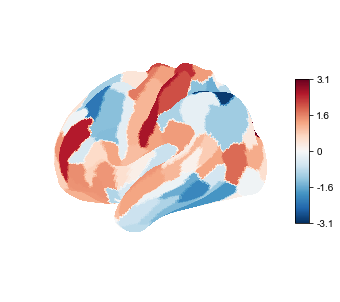

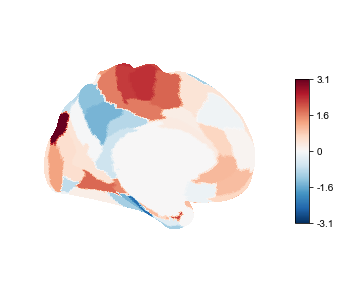

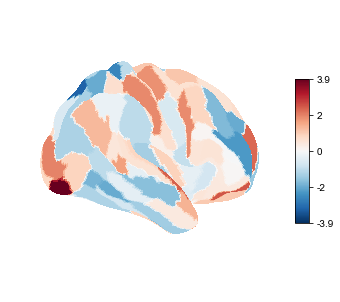

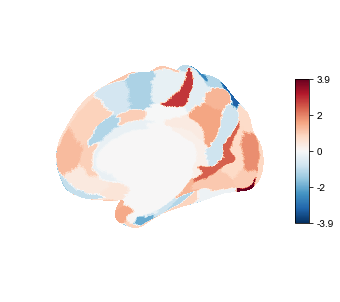

In [39]:
from nilearn import surface, plotting

# read the BNA atlas on the surface
BNA_atlas_L = surface.load_surf_data('/n02dat01/users/dyli/Atlas/fsaverage.L.BN_Atlas.32k_fs_LR_new.label.gii')
print(BNA_atlas_L.shape)
print(np.unique(BNA_atlas_L))
BNA_atlas_R = surface.load_surf_data('/n02dat01/users/dyli/Atlas/fsaverage.R.BN_Atlas.32k_fs_LR_new.label.gii')
print(BNA_atlas_R.shape)
print(np.unique(BNA_atlas_R))

t_map = np.load('/n01dat01/camilla/973/FC_BNA/ttest_results/ttest_results_FC_r_A46_L.npy')[:, 0] # size: (246, )
print(t_map.shape)
# for left hemisphere odd number
t_map_L = np.array([t_map[2*i+1] for i in range(105)]) # size: (105, )
print(t_map_L.shape)
brain_map_L = np.zeros(32492)
for i in range(105):
    brain_map_L[BNA_atlas_L==2*i+1] = t_map_L[i]

# for right hemisphere
t_map_R = np.array([t_map[2*i+2] for i in range(105)]) # size: (105, )
print(t_map_R.shape)
brain_map_R = np.zeros(32492)
for i in range(105):
    brain_map_R[BNA_atlas_R==2*i+2] = t_map_R[i]

print(f'the correlation between lh and rh: {np.corrcoef(t_map_L, t_map_R)[0,1]}, {np.corrcoef(brain_map_L, brain_map_R)[0,1]}')

# plotting
surface_name = 'inflated' # midthickness, white, pial
# left hemisphere
fig_L = plotting.plot_surf_stat_map(f'/n02dat01/users/dyli/MNI152/MNINonLinear/fsaverage_LR32k/MNI152.L.{surface_name}.32k_fs_LR.surf.gii',
                                    brain_map_L,
                                    hemi='left',
                                    title='',
                                    colorbar=True,
                                    cmap='RdBu_r')
fig_L.show()
fig_L = plotting.plot_surf_stat_map(f'/n02dat01/users/dyli/MNI152/MNINonLinear/fsaverage_LR32k/MNI152.L.{surface_name}.32k_fs_LR.surf.gii',
                                    brain_map_L,
                                    hemi='left',
                                    view='medial',
                                    title='',
                                    colorbar=True,
                                    cmap='RdBu_r')
fig_L.show()
# right hemisphere
fig_R = plotting.plot_surf_stat_map(f'/n02dat01/users/dyli/MNI152/MNINonLinear/fsaverage_LR32k/MNI152.R.{surface_name}.32k_fs_LR.surf.gii',
                                    brain_map_R,
                                    hemi='right',
                                    title='',
                                    colorbar=True,
                                    cmap='RdBu_r')
fig_R.show()
fig_R = plotting.plot_surf_stat_map(f'/n02dat01/users/dyli/MNI152/MNINonLinear/fsaverage_LR32k/MNI152.R.{surface_name}.32k_fs_LR.surf.gii',
                                    brain_map_R,
                                    hemi='right',
                                    view='medial',
                                    title='',
                                    colorbar=True,
                                    cmap='RdBu_r')
fig_R.show()